In [1]:
import pandas as pd

In [2]:
train_df = pd.read_csv("/Users/apple/Documents/Projects/Nasa RUL MLE/data/processed/feature_engineered_train.csv")
test_df = pd.read_csv("/Users/apple/Documents/Projects/Nasa RUL MLE/data/processed/feature_engineered_test.csv")
rul_df = pd.read_csv("/Users/apple/Documents/Projects/Nasa RUL MLE/data/processed/clean_rul.csv")

In [3]:
# Features & target
X = train_df.drop(columns=["engine_id", "rul"])
y = train_df["rul"]

test_last = test_df.groupby("engine_id").last().reset_index()
X_test = test_last.drop(columns=["engine_id"])
y_test = rul_df["rul"]

In [4]:
print("X shape:", X.shape)
print("X_test shape:", X_test.shape)

X shape: (20631, 43)
X_test shape: (100, 43)


In [5]:
# Train / Evaluation split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# Evaluation metrics function
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def evaluate(model, X_val, y_val):
    preds = model.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    mae = mean_absolute_error(y_val, preds)
    
    return rmse, mae

In [7]:
# Linear regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

rmse_train_lr, mae_train_lr = evaluate(lr, X_val, y_val)
rmse_test_lr, mae_test_lr = evaluate(lr, X_test, y_test)

In [8]:
# Random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rmse_train_rf, mae_train_rf = evaluate(rf, X_val, y_val)
rmse_test_rf, mae_test_rf = evaluate(rf, X_test, y_test)

In [9]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

sensor_4_rolling_mean     0.633974
cycle                     0.135132
sensor_11_rolling_mean    0.092520
sensor_9_rolling_mean     0.036001
sensor_15_rolling_mean    0.023670
sensor_14_rolling_mean    0.012794
sensor_7_rolling_mean     0.007986
sensor_12_rolling_mean    0.007094
sensor_2_rolling_mean     0.006265
sensor_3_rolling_mean     0.005900
dtype: float64

In [10]:
# XGBoost
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

rmse_train_xgb, mae_train_xgb = evaluate(xgb, X_val, y_val)
rmse_test_xgb, mae_test_xgb = evaluate(xgb, X_test, y_test)

In [11]:
# Ridge regression
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

rmse_train_ridge, mae_train_ridge = evaluate(ridge, X_val, y_val)
rmse_test_ridge, mae_test_ridge = evaluate(ridge, X_test, y_test)

In [12]:
results = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Random Forest", "XGBoost"],
    "RMSE Train": [rmse_train_lr, rmse_train_ridge, rmse_train_rf, rmse_train_xgb],
    "RMSE Test": [rmse_test_lr, rmse_test_ridge, rmse_test_rf, rmse_test_xgb],
    "MAE Train": [mae_train_lr, mae_train_ridge, mae_train_rf, mae_train_xgb],
    "MAE Test": [mae_test_lr, mae_test_ridge, mae_test_rf, mae_test_xgb]
})

results.sort_values(by="RMSE Test")

,Model,RMSE Train,RMSE Test,MAE Train,MAE Test
2,Random Forest,14.005622,19.110651,9.204712,14.060813
3,XGBoost,14.112818,19.307330,9.380214,14.151427
0,Linear,19.760370,22.227491,16.011420,17.339999
1,Ridge,19.760127,22.227980,16.011219,17.340325


In [13]:
best_model1 = rf  # example

preds_test = best_model1.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))
mae_test = mean_absolute_error(y_test, preds_test)

print("Test RMSE:", rmse_test)
print("Test MAE:", mae_test)

Test RMSE: 19.110650901722977
Test MAE: 14.060812769578709


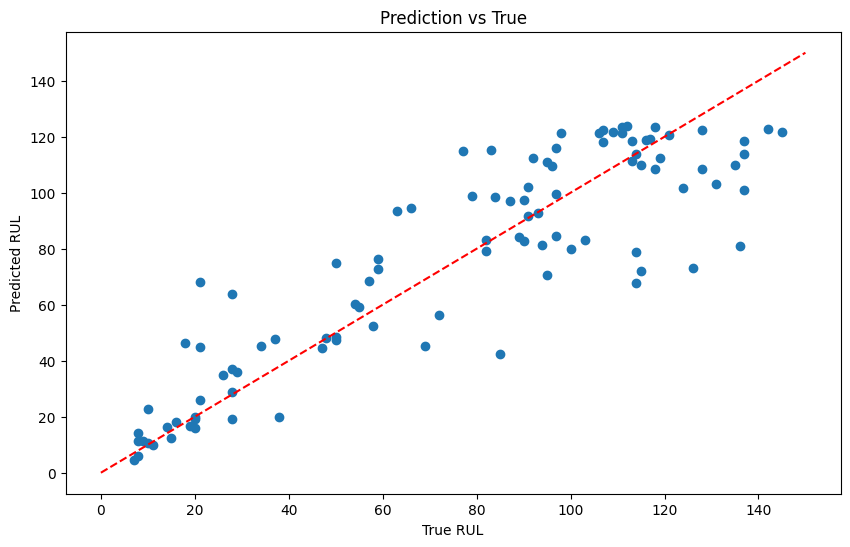

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(y_test, preds_test)
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Prediction vs True")
plt.plot([0,150], [0,150], 'r--')
plt.show()

In [15]:
best_model2 = xgb  # example

preds_test = best_model2.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))
mae_test = mean_absolute_error(y_test, preds_test)

print("Test RMSE:", rmse_test)
print("Test MAE:", mae_test)

Test RMSE: 19.307330479740234
Test MAE: 14.151427268981934


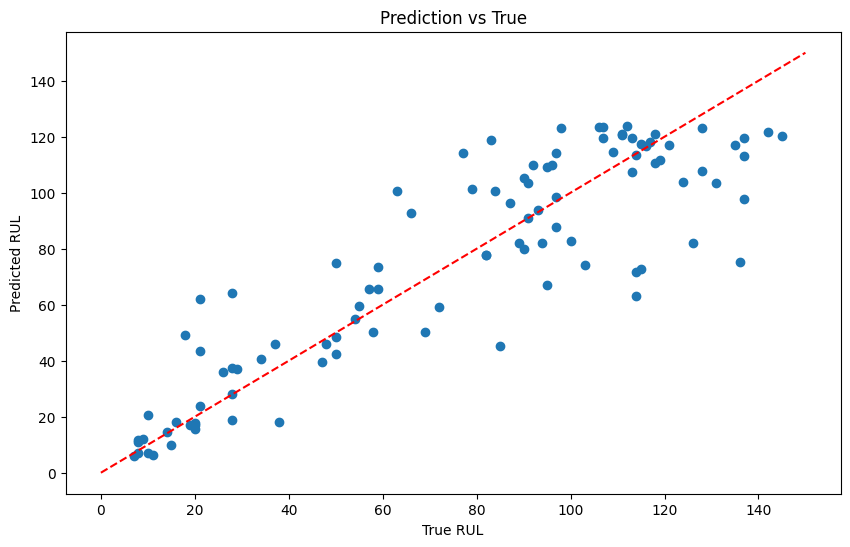

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(y_test, preds_test)
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Prediction vs True")
plt.plot([0,150], [0,150], 'r--')
plt.show()